<h1>Graphically Solving a Multidimensional Linear Optimization Problem with Interactive Constraints</h1>

<p>
Author: John Bonfardeci, M.Sc. (john.bonfardeci@gmail.com)<br />
Created: 2024-01-21
</p>

<p>This is a continuation of the notebook <strong>Graphically Solving a Linear Optimization Problem with Interactive Constraints</strong></p>

In [1]:
import pandas as pd
from pandas import DataFrame
from sympy import Symbol, solve
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn.objects as so
import seaborn as sns
from typing import List, Dict, Any

In [2]:
printer_table = pd.DataFrame(data=[
    [1, "Printer1", 8],
    [2, "Printer2", 8],
    [3, "Printer3", 12],
    [4, "Printer4", 12],
    [5, "Printer5", 9],
    [6, "Printer6", 11],
    [7, "Printer7", 7],
    [8, "Printer8", 6],
], columns=["printer_id", "printer_name", "available_hours"])
display(printer_table.head())

,printer_id,printer_name,available_hours
0,1,Printer1,8
1,2,Printer2,8
2,3,Printer3,12
3,4,Printer4,12
4,5,Printer5,9


In [3]:
product_table = pd.DataFrame(data=[
    [1, "Product1", 75],
    [2, "Product2", 50],
    [3, "Product3", 150],
    [4, "Product4", 250],
], columns=["product_id", "product_name", "unit_profit"])
display(product_table.head())

,product_id,product_name,unit_profit
0,1,Product1,75
1,2,Product2,50
2,3,Product3,150
3,4,Product4,250


In [4]:
import random as rn
rn.seed(42)
printer_product_data = []

for print_id, *_ in printer_table.to_numpy():
    for prod_id, *_ in product_table.to_numpy():
        printer_product_data.append({
            "printer_id": print_id,
            "product_id": prod_id,
            "hours_req": rn.randint(1,3)
        })
    # for
# for

printer_product_table = pd.DataFrame(data=printer_product_data)
display(printer_product_table.head())

,printer_id,product_id,hours_req
0,1,1,3
1,1,2,1
2,1,3,1
3,1,4,3
4,2,1,2


In [5]:
dataset = pd.merge(printer_table, printer_product_table, on=['printer_id'], how='inner')
dataset = pd.merge(dataset, product_table, on=['product_id'], how='inner')
display(dataset.head())

,printer_id,printer_name,available_hours,product_id,hours_req,product_name,unit_profit
0,1,Printer1,8,1,3,Product1,75
1,1,Printer1,8,2,1,Product2,50
2,1,Printer1,8,3,1,Product3,150
3,1,Printer1,8,4,3,Product4,250
4,2,Printer2,8,1,2,Product1,75


In [6]:
profits = [n[0] for n in dataset[['printer_id', 'unit_profit']].groupby('printer_id').sum('unit_profit').values]

In [7]:
def get_bound(x1, x2, limit):
    x_1 = [limit/x1, 0.0]
    x_2 = [0.0, limit/x2]
    return x_1, x_2


def get_constraint(x: Symbol, print_id: int):
    rows = dataset[dataset.printer_id == print_id]
    available_hours = printer_table[printer_table['printer_id'] == print_id]['available_hours'].values[0]
    constraint = None
    for _, _, avail_hrs, _, hrs_req, *_ in rows.to_numpy():
        if constraint is None:
            constraint = hrs_req * x
        else:
            constraint += hrs_req * x
    # for
    return constraint - available_hours


def chunk_list(lst: List[Any], chunk_size: int=2) -> List[List[Any]]:
    chunked_list = []
    for i in range(0, len(lst), chunk_size):
        res = lst[i:i+chunk_size]
        chunked_list.append(res)
    return chunked_list

In [8]:
def plot_funnel_chart(soln, constraints, profits):
    Y = []
    Ylabels = []
    for (k, v), profit in zip(soln.items(), profits):
        Y.append(float(v)*profit)
        expr = str(constraints[str(k)]['expr'])
        Ylabels.append(f'{k} = {expr}')

    plotly_df = pd.DataFrame(data=np.array(Y).reshape(8,1), columns=['profit'])
    plotly_df.index=Ylabels
    plotly_df.sort_values(by='profit', inplace=True)
    total_profit = plotly_df['profit'].sum()
    plotly_data = plotly_df.to_dict()['profit']
    fig = px.funnel(x=[v for v in plotly_data.values()] + [total_profit], y=[k for k in plotly_data.keys()] + ['Total Profit'])
    fig.update_layout(
        title="Max Profit Per Printer with Total Profit",
        xaxis_title="Profit",
        yaxis_title="Constraints",
        legend_title="Legend",
        font=dict(
            family="Sans-serif",
            size=14,
            color="black"
        )
    )
    fig.show()

In [9]:
# Determine the Objective Function and Decision Variables
# Max Z: p1*x1 + p2*x2 + p3*x3, ... + pNxN
def get_solutions(dataset: DataFrame):
  decision_expr = None
  constraints = {}
  for print_id, _, avail_hrs, _, hrs_req, _, profit, *_ in dataset.to_numpy():
      xid = f'x{print_id}'
      x = Symbol(xid)
      expr = profit*x
      if decision_expr is None:
          decision_expr = expr
      else:
          decision_expr = decision_expr + expr

      if xid in constraints:
          constraints[xid]['beta'] += hrs_req
      else:
          constraints[xid] = {
              'expr': get_constraint(x, print_id),
              'beta': hrs_req,
              'limit': avail_hrs,
              'symbol': x
          }
  # for
  # Solve for constraints.
  soln = solve((v['expr'] for v in constraints.values()), dict=True)[0]
  max_profit = float(decision_expr.subs(soln))
  print(max_profit)
  return dict(decision_expr=decision_expr,
              constraints=constraints,
              soln=soln,
              max_profit=max_profit)

5315.625


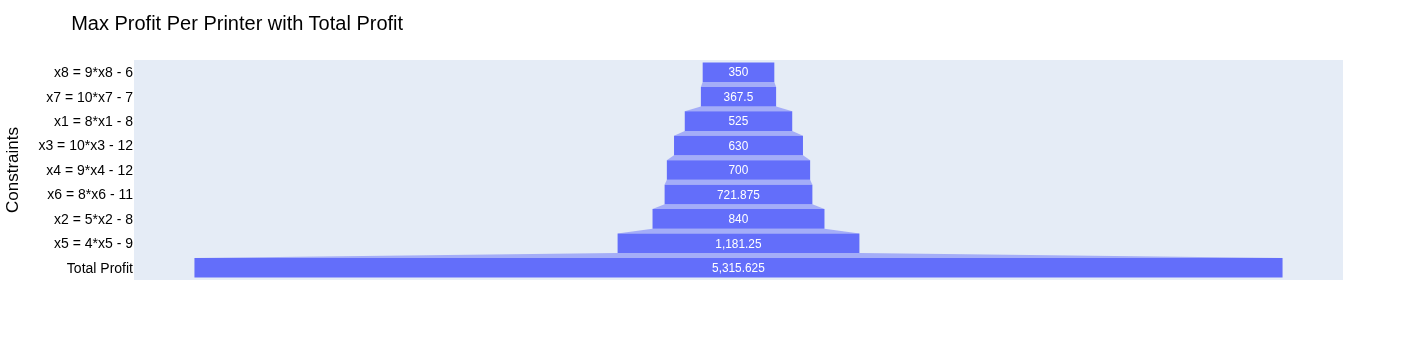

In [10]:
solutions = get_solutions(dataset)
plot_funnel_chart(
    soln=solutions['soln'],
    constraints=solutions['constraints'],
    profits=profits
)

In [11]:
import ipywidgets as widgets

SLIDERS = {}
for ix, print_name, avail_hrs in printer_table.to_numpy():
  xid = f'x{ix}'
  slider = widgets.IntSlider(
    value=avail_hrs,
    min=1, max=24, step=1,
    description=f'{xid}: {print_name}'
  )
  SLIDERS[str(ix)] = slider

# display(sliders)

In [12]:
def show_plot(df):
  _ = so.Plot(df, x='profit', y=df.index, color=df.index).add(so.Bar(), so.Stack())


def compute(**sliders):
  df = dataset.copy()
  for ix, val in sliders.items():
    df.at[int(ix)-1, 'available_hours'] = val
    print(val)
  # for
  solutions = get_solutions(df)
  soln = solutions['soln']
  constraints = solutions['constraints']
  plot_funnel_chart(
    soln=soln,
    constraints=constraints,
    profits=profits
  )


widgets.interactive(compute, **{id: slider.value for id, slider in SLIDERS.items()})

interactive(children=(IntSlider(value=8, description='1', max=24, min=-8), IntSlider(value=8, description='2',…